---
## Part A: NumPy Array Operations (30 points)

### Question 1: Revenue Simulation (10 points)

You run a small Nigerian market stall selling 4 products. Simulate 30 days of business:

**Requirements:**
1. Generate daily sales quantities for 4 products (use normal distribution)
   - Product A: mean=50, std=10
   - Product B: mean=30, std=5
   - Product C: mean=70, std=15
   - Product D: mean=40, std=8
2. Set random seed to your favorite number
3. Ensure no negative quantities (clip at 0)
4. Print the shape and first 5 days

**Deliverable:** Create a 30×4 NumPy array called `daily_sales`

In [213]:
import numpy as np

# Your code here
# Set seed
np.random.seed(42)

# Generate sales data
daily_sales = np.random.randint(5, 50, size=(30,4))

# Display results
print("Sales Data (30 days, 4 products):")
print(daily_sales)

Sales Data (30 days, 4 products):
[[43 33 19 47]
 [12 25 43 23]
 [27 15 15 28]
 [40 44 28  7]
 [26  6 28 48]
 [34 42  6 25]
 [37 16 26 48]
 [29 31 46 32]
 [20 19 48  7]
 [41 11 25 13]
 [43 22  8 29]
 [18 13 30  6]
 [24 32 11 48]
 [12 39 18 21]
 [40 44  8  6]
 [10 46  8 33]
 [22 30 48 38]
 [14 40 18 35]
 [19 12 18 27]
 [44 25 20 49]
 [22 28 30 29]
 [49 45 33 19]
 [49  5 29 11]
 [13 28  5 48]
 [12 28 15 21]
 [12 39 39 37]
 [ 9 46 43 45]
 [32 11 13 12]
 [16 38 37 27]
 [28 41 39 48]]


In [214]:
print(daily_sales[:5])

[[43 33 19 47]
 [12 25 43 23]
 [27 15 15 28]
 [40 44 28  7]
 [26  6 28 48]]


### Question 2: Financial Analysis (10 points)

Using the `daily_sales` array from Q1:

**Calculate:**
1. Total sales for each product over 30 days
2. Average daily sales per product
3. The day with maximum total sales (across all products)
4. How many days had total sales above the 30-day average?
5. Standard deviation of sales for each product

**Deliverable:** Print all results with clear labels

In [215]:
# Your code here
#1 Calculate total sales for each product for 30 days
total_sales = np.sum(daily_sales, axis=0)
print("\nTotal Sales for Each Product:")
print(total_sales)

#2 Calculate average daily sales per product
average_sales = np.mean(daily_sales, axis=0)
print("\nAverage Daily Sales for Each Product:")
print(average_sales)

#3 Identify day with maximum total sales across all products
total_sales_per_day = np.sum(daily_sales, axis=1)
max_sales_day = np.argmax(total_sales_per_day)
print("\nDay with Maximum Total Sales Across All Products:")
print(f"Day {max_sales_day + 1} with total sales of {total_sales_per_day[max_sales_day]}")

#4 How many days had total sales above the 30-day average?
average_daily_sales = np.mean(total_sales_per_day)
days_exceeding_average = np.sum(total_sales_per_day > average_daily_sales)
print(f"\nNumber of Days Where Total Sales Exceeded 30-Day Average: {days_exceeding_average}")

#5 Standard deviation of daily sales for each product
std_dev_sales = np.std(daily_sales, axis=0)
print("\nStandard Deviation of Daily Sales for Each Product:")
print(std_dev_sales)


Total Sales for Each Product:
[797 854 754 867]

Average Daily Sales for Each Product:
[26.56666667 28.46666667 25.13333333 28.9       ]

Day with Maximum Total Sales Across All Products:
Day 30 with total sales of 156

Number of Days Where Total Sales Exceeded 30-Day Average: 12

Standard Deviation of Daily Sales for Each Product:
[12.55569813 12.73769559 13.17506062 14.3465443 ]


### Question 3: Price & Revenue Calculation (10 points)

Your products have these prices: [200, 350, 150, 280] NGN

**Tasks:**
1. Calculate daily revenue (price × quantity for each product)
2. Calculate total revenue over 30 days
3. Apply a promotional discount:
   - Days 1-5: 15% off all products
   - Days 15-20: 10% off Product A and B only
   - Other days: no discount
4. Calculate total revenue with discounts
5. How much discount did you give away?

**Hint:** Use boolean indexing and broadcasting

In [216]:
# Your code here
prices = np.array([200, 350, 150, 280])

# 1. Daily revenue for each product (price * quantity of each product)
daily_revenue = daily_sales * prices
print("Daily Revenue for Each Product:")
print(daily_revenue)

# 2. Total revenue for each product over 30 days
total_revenue = np.sum(daily_revenue, axis=1)
print("\nTotal Revenue for Each Product Over 30 Days:")
print(total_revenue)

# 3. Apply promotional discount
# Days 1-5: 15% off all products
# Days 15-20: 10% off Product A and B only
# other days no discount
# convert to float before applying fractional discounts to avoid casting errors
discounted_revenue = daily_revenue.astype(float)
# Apply 15% discount for days 1-5
discounted_revenue[0:5, :] *= 0.85
# Apply 10% discount for Product A and B on days 15-20
discounted_revenue[14:20, 0:2] *= 0.90
print("\nDiscounted Revenue for Each Product:")
print(discounted_revenue)

# 4. Total revenue with discounts applied
total_discounted_revenue = np.sum(discounted_revenue, axis=1)
print("\nTotal Revenue with Discounts Applied:")
print(total_discounted_revenue)

# 5.  amount of discount given away
total_discount_given = np.sum(daily_revenue - discounted_revenue, axis=1)
print("\nTotal Discount Given Away:")
print(total_discount_given)


Daily Revenue for Each Product:
[[ 8600 11550  2850 13160]
 [ 2400  8750  6450  6440]
 [ 5400  5250  2250  7840]
 [ 8000 15400  4200  1960]
 [ 5200  2100  4200 13440]
 [ 6800 14700   900  7000]
 [ 7400  5600  3900 13440]
 [ 5800 10850  6900  8960]
 [ 4000  6650  7200  1960]
 [ 8200  3850  3750  3640]
 [ 8600  7700  1200  8120]
 [ 3600  4550  4500  1680]
 [ 4800 11200  1650 13440]
 [ 2400 13650  2700  5880]
 [ 8000 15400  1200  1680]
 [ 2000 16100  1200  9240]
 [ 4400 10500  7200 10640]
 [ 2800 14000  2700  9800]
 [ 3800  4200  2700  7560]
 [ 8800  8750  3000 13720]
 [ 4400  9800  4500  8120]
 [ 9800 15750  4950  5320]
 [ 9800  1750  4350  3080]
 [ 2600  9800   750 13440]
 [ 2400  9800  2250  5880]
 [ 2400 13650  5850 10360]
 [ 1800 16100  6450 12600]
 [ 6400  3850  1950  3360]
 [ 3200 13300  5550  7560]
 [ 5600 14350  5850 13440]]

Total Revenue for Each Product Over 30 Days:
[36160 24040 20740 29560 24940 29400 30340 32510 19810 19440 25620 14330
 31090 24630 26280 28540 32740 29300 1

---
## Part B: Pandas Data Analysis (50 points)

### Question 4: Load and Explore Your Dataset (10 points)

**Task:** Find a dataset relevant to your problem domain, or use one of the provided datasets.

**Requirements:**
1. Load the dataset using Pandas
2. Display basic information:
   - Number of rows and columns
   - Column names and data types
   - First 10 rows
   - Statistical summary
   - Check for missing values
3. Write 2-3 sentences describing what this dataset contains

**Deliverable:** Load data into a DataFrame called `df` and provide the exploration

In [217]:
import pandas as pd

# Your code here
# If you don't have your own dataset, use: 'nigerian_market_prices.csv' or 'nigerian_population_data.csv'
df = pd.read_csv("C:\\Users\\GOIT\\Downloads\\ai4sid\\class_training\\mahis-class\\05_datasets\\week_02\\NumPy & Pandas\\nigerian_market_prices_assignment.csv")


In [218]:
#Display basic information:
#- Number of rows and columns
print("Number of rows and columns:", df.shape)

Number of rows and columns: (1000, 8)


In [219]:
#- Column names and data types
print("Column names and data types:",df.dtypes)

Column names and data types: market_id      object
market_name    object
state          object
product        object
price          object
unit           object
date           object
trader_name    object
dtype: object


In [220]:

#- First 10 rows
print("First 10 rows:", df.head(10))

First 10 rows:   market_id    market_name  state   product    price          unit  \
0    MKT001  Bodija Market    Oyo     Beans   ₦5,770            Kg   
1    MKT003  Ogbete Market  Enugu       Yam   ₦2,534        basket   
2    MKT001  Bodija Market    Oyo       Yam      NaN          50kg   
3    MKT004    Wuse Market  Abuja  Tomatoes      NaN  Paint Rubber   
4    MKT003  Ogbete Market  Enugu      Gari    -2616            kg   
5    MKT002        Mile 12  Lagos  Tomatoes   ₦6,166        Basket   
6    MKT003  Ogbete Market  Enugu      Gari   ₦5,367            kg   
7    MKT004    Wuse Market  Abuja      Gari    -1901        Basket   
8    MKT003  Ogbete Market  Enugu      Rice  ₦43,890            kg   
9    MKT002        Mile 12  Lagos  Tomatoes     6292          50kg   

         date  trader_name  
0  01-02-2024  mama nkechi  
1  07/02/2024        bello  
2  22/02/2024  alhaji musa  
3  29-01-2024  mama nkechi  
4  2024/01/31       sadiya  
5  11-01-2024       SADIYA  
6  2024/03/

In [221]:
#- Statistical summary
print("Statistical summary:",df.describe())

Statistical summary:        market_id    market_name state product price    unit        date  \
count       1000           1000  1000    1000   925    1000        1000   
unique         5              5     5       5   909       6         342   
top       MKT001  Bodija Market   Oyo    Rice  1035  basket  2024-01-26   
freq         207            207   207     216     2     176           8   

       trader_name  
count         1000  
unique          10  
top         sadiya  
freq           153  


In [222]:
#- Check for missing values
print("Missing values:",df.isnull().sum())

Missing values: market_id       0
market_name     0
state           0
product         0
price          75
unit            0
date            0
trader_name     0
dtype: int64


### Question 5: Data Filtering & Selection (10 points)

Using your loaded dataset:

**Tasks:**
1. Select 3 columns of interest and display first 10 rows
2. Filter data based on a numeric condition (e.g., price > some_value)
3. Filter data based on a categorical condition (e.g., state == 'Lagos')
4. Combine two conditions using AND (&) or OR (|)
5. Display the shape of each filtered dataset

**Deliverable:** Show 4 different filtered views of your data

In [223]:
# Your code here

# Cleaning data for analysis
# 5.1 Select 3 columns of interest and display the first 10 rows
# --- i. CLEANING THE PRICE COLUMN ---
# Remove currency symbols (₦) and commas, then convert to numeric
df['price'] = df['price'].astype(str).str.replace('₦', '').str.replace(',', '')
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Handle negative values (likely entry errors) by making them absolute
df['price'] = df['price'].abs()

# Fill missing values with the median price for each specific product
df['price'] = df.groupby('product')['price'].transform(lambda x: x.fillna(x.median()))

# --- ii. CLEANING THE DATE COLUMN ---
# Standardize mixed date formats into a single datetime object
df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=False)

# --- iii. NORMALIZING TEXT COLUMNS ---
# Fix inconsistent casing (e.g., 'SADIYA' vs 'sadiya') and whitespace
text_cols = ['market_name', 'state', 'product', 'unit', 'trader_name']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

df.info()  # Check cleaned data types and missing values
df.head(10)  # Check cleaned data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   market_id    1000 non-null   object        
 1   market_name  1000 non-null   object        
 2   state        1000 non-null   object        
 3   product      1000 non-null   object        
 4   price        1000 non-null   float64       
 5   unit         1000 non-null   object        
 6   date         1000 non-null   datetime64[ns]
 7   trader_name  1000 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 62.6+ KB


,market_id,market_name,state,product,price,unit,date,trader_name
0,MKT001,Bodija Market,Oyo,Beans,5770.0,Kg,2024-01-02,Mama Nkechi
1,MKT003,Ogbete Market,Enugu,Yam,2534.0,Basket,2024-07-02,Bello
2,MKT001,Bodija Market,Oyo,Yam,2524.5,50Kg,2024-02-22,Alhaji Musa
3,MKT004,Wuse Market,Abuja,Tomatoes,2312.0,Paint Rubber,2024-01-29,Mama Nkechi
4,MKT003,Ogbete Market,Enugu,Gari,2616.0,Kg,2024-01-31,Sadiya
5,MKT002,Mile 12,Lagos,Tomatoes,6166.0,Basket,2024-11-01,Sadiya
6,MKT003,Ogbete Market,Enugu,Gari,5367.0,Kg,2024-03-19,Alhaji Musa
7,MKT004,Wuse Market,Abuja,Gari,1901.0,Basket,2024-03-13,Chinedu
8,MKT003,Ogbete Market,Enugu,Rice,43890.0,Kg,2024-03-15,Sadiya
9,MKT002,Mile 12,Lagos,Tomatoes,6292.0,50Kg,2024-03-31,Bello


In [224]:
# 5.1 Select 3 columns of interest and display the first 10 rows
columns_of_interest = ['date', 'product', 'price']
print("\nSelected Columns (First 10 Rows):")
print(df[columns_of_interest].head(10))


Selected Columns (First 10 Rows):
        date   product    price
0 2024-01-02     Beans   5770.0
1 2024-07-02       Yam   2534.0
2 2024-02-22       Yam   2524.5
3 2024-01-29  Tomatoes   2312.0
4 2024-01-31      Gari   2616.0
5 2024-11-01  Tomatoes   6166.0
6 2024-03-19      Gari   5367.0
7 2024-03-13      Gari   1901.0
8 2024-03-15      Rice  43890.0
9 2024-03-31  Tomatoes   6292.0


In [225]:
# 5.2 Filter data based on a numeric condition (e.g., price > some_value)
# The price column contains symbols and commas, so we need to clean it before filtering
df['price'] = pd.to_numeric(df['price'].replace('[₦,]', '', regex=True), errors='coerce')
df_filtered = df[df['price'] > 100]
print("Filtered data (price > 100):")
print(df_filtered.head(10))

Filtered data (price > 100):
  market_id    market_name  state   product    price          unit       date  \
0    MKT001  Bodija Market    Oyo     Beans   5770.0            Kg 2024-01-02   
1    MKT003  Ogbete Market  Enugu       Yam   2534.0        Basket 2024-07-02   
2    MKT001  Bodija Market    Oyo       Yam   2524.5          50Kg 2024-02-22   
3    MKT004    Wuse Market  Abuja  Tomatoes   2312.0  Paint Rubber 2024-01-29   
4    MKT003  Ogbete Market  Enugu      Gari   2616.0            Kg 2024-01-31   
5    MKT002        Mile 12  Lagos  Tomatoes   6166.0        Basket 2024-11-01   
6    MKT003  Ogbete Market  Enugu      Gari   5367.0            Kg 2024-03-19   
7    MKT004    Wuse Market  Abuja      Gari   1901.0        Basket 2024-03-13   
8    MKT003  Ogbete Market  Enugu      Rice  43890.0            Kg 2024-03-15   
9    MKT002        Mile 12  Lagos  Tomatoes   6292.0          50Kg 2024-03-31   

   trader_name  
0  Mama Nkechi  
1        Bello  
2  Alhaji Musa  
3  Mama Nke

In [226]:
# 5.3 Filter data based on a categorical condition (e.g., state == 'Lagos')
lagos_market = df[df['state'] == 'Lagos']
print("Data for Lagos market:")
print(lagos_market.head(10))

Data for Lagos market:
   market_id market_name  state   product    price          unit       date  \
5     MKT002     Mile 12  Lagos  Tomatoes   6166.0        Basket 2024-11-01   
9     MKT002     Mile 12  Lagos  Tomatoes   6292.0          50Kg 2024-03-31   
11    MKT002     Mile 12  Lagos      Rice  44896.0  Paint Rubber 2024-03-10   
20    MKT002     Mile 12  Lagos      Rice  40391.0            Kg 2024-02-18   
26    MKT002     Mile 12  Lagos      Gari    688.0            Kg 2024-01-17   
32    MKT002     Mile 12  Lagos      Gari    173.0          50Kg 2024-02-08   
33    MKT002     Mile 12  Lagos  Tomatoes   3092.0            Kg 2024-02-13   
35    MKT002     Mile 12  Lagos      Gari   1775.0        Basket 2024-03-22   
52    MKT002     Mile 12  Lagos       Yam   3958.0            Kg 2024-12-03   
59    MKT002     Mile 12  Lagos       Yam   1296.0  Paint Rubber 2024-01-13   

    trader_name  
5        Sadiya  
9         Bello  
11  Mama Nkechi  
20       Sadiya  
26       Sadiya  

In [227]:
# 5.4 Combine two conditions using AND (&) or OR (|)
# Filter data for Lagos market AND product is Yam or Gari 
filtered_data = df[(df['state'] == 'Lagos') & ((df['product'] == 'Yam') | (df['product'] == 'Gari'))]
print("Filtered data (Lagos and product is Yam or Gari):")
print(filtered_data.head(10))

Filtered data (Lagos and product is Yam or Gari):
    market_id market_name  state product   price          unit       date  \
26     MKT002     Mile 12  Lagos    Gari   688.0            Kg 2024-01-17   
32     MKT002     Mile 12  Lagos    Gari   173.0          50Kg 2024-02-08   
35     MKT002     Mile 12  Lagos    Gari  1775.0        Basket 2024-03-22   
52     MKT002     Mile 12  Lagos     Yam  3958.0            Kg 2024-12-03   
59     MKT002     Mile 12  Lagos     Yam  1296.0  Paint Rubber 2024-01-13   
61     MKT002     Mile 12  Lagos     Yam  5554.0            Kg 2024-03-27   
69     MKT002     Mile 12  Lagos     Yam  1384.0            Kg 2024-03-18   
76     MKT002     Mile 12  Lagos    Gari  5363.0            Kg 2024-02-19   
90     MKT002     Mile 12  Lagos    Gari  2323.5        Basket 2024-03-14   
117    MKT002     Mile 12  Lagos     Yam  3856.0            Kg 2024-02-21   

     trader_name  
26        Sadiya  
32   Mama Nkechi  
35       Chinedu  
52         Bello  
59   Al

In [228]:
# 5.5 Display the shape of each filtered dataset
print("Shape of price > 100:", df_filtered.shape)
print("Shape of Lagos market:", lagos_market.shape)
print("Shape of Lagos and product is Yam or Gari:", filtered_data.shape)


Shape of price > 100: (985, 8)
Shape of Lagos market: (196, 8)
Shape of Lagos and product is Yam or Gari: (73, 8)


### Question 6: Aggregation & Grouping (15 points)

Using your dataset:

**Tasks:**
1. Group by a categorical column and calculate mean of a numeric column
2. Group by a categorical column and calculate multiple statistics (min, max, mean, sum)
3. Create a cross-tabulation or pivot table (if applicable)
4. Find the top 5 records by some criterion
5. Calculate at least one percentage or ratio

**Deliverable:** Perform 5 different aggregations/groupings

In [229]:
# Your code here
# 6.1 Group data by 'state' and calculate average price for each state
average_price_by_state = df.groupby('state')['price'].mean()
print("Average Price by State:")
print(average_price_by_state)


Average Price by State:
state
Abia      8981.740741
Abuja    12355.536232
Enugu    11794.012438
Lagos    13456.558673
Oyo      13032.422705
Name: price, dtype: float64


In [230]:
# 6.2 Group data by 'product' and calculate MIN, MAX, MEAN, & SUM
product_stats = df.groupby('product')['price'].agg(['min', 'max', 'mean', 'sum'])
print("\nProduct Price Statistics:")
print(product_stats)



Product Price Statistics:
              min      max          mean        sum
product                                            
Beans        21.0   8440.0   3569.204082   699564.0
Gari          2.0   6191.0   2452.432642   473319.5
Rice      40001.0  49911.0  44810.657407  9679102.0
Tomatoes     20.0   7449.0   2757.531401   570809.0
Yam          41.0   6791.0   2862.468085   538144.0


In [231]:
#6.3 Create cross tabulation of average price by 'state' and 'product'
cross_tab = pd.crosstab(df['state'], df['product'], values=df['price'], aggfunc='mean')
print("\nCross Tabulation of Average Price by State and Product:")
print(cross_tab)


Cross Tabulation of Average Price by State and Product:
product        Beans         Gari          Rice     Tomatoes          Yam
state                                                                    
Abia     2556.564103  2520.655556  45319.642857  2498.500000  3157.900000
Abuja    3389.461538  2419.047619  44603.297872  2667.782609  3173.757576
Enugu    4212.500000  2538.410256  45069.500000  2619.139535  2636.662162
Lagos    3191.200000  2550.225806  44753.816327  3529.352941  2805.845238
Oyo      4513.710526  2228.750000  44558.820000  2631.738095  2621.500000


In [232]:
#6.4 Find the state with the most expensive product
most_expensive_product = df.groupby('state')['price'].max().idxmax()
print("\nState with the Most Expensive Product:")
print(most_expensive_product)



State with the Most Expensive Product:
Abuja


In [233]:
#6.4 Calculate the percentage of missing values in each column
missing_percentage = df.isnull().mean() * 100
print("\nPercentage of Missing Values in Each Column:")
print(missing_percentage)


Percentage of Missing Values in Each Column:
market_id      0.0
market_name    0.0
state          0.0
product        0.0
price          0.0
unit           0.0
date           0.0
trader_name    0.0
dtype: float64


### Question 7: Data Transformation (15 points)

Using your dataset:

**Tasks:**
1. Create a new column based on a calculation (e.g., total = price × quantity)
2. Create a categorical column based on numeric ranges (e.g., 'Low', 'Medium', 'High')
3. Sort data by 2 or more columns
4. Calculate a rolling or cumulative statistic (if time-series data)
5. Handle any missing values (if present) using appropriate methods

**Deliverable:** Show your transformed dataset with new columns

In [234]:
# Your code here
# 7.1 Create a new column that Rank prices within each state
df['state_price_rank'] = df.groupby('state')['price'].rank(method='dense', ascending=False)

df[['state','product','price','state_price_rank']].head()


,state,product,price,state_price_rank
0,Oyo,Beans,5770.0,72.0
1,Enugu,Yam,2534.0,115.0
2,Oyo,Yam,2524.5,119.0
3,Abuja,Tomatoes,2312.0,120.0
4,Enugu,Gari,2616.0,112.0


In [235]:
# 7.2 Create a new column 'price_category' based on price ranges
# Because the unit column currently have mixed values, a new column was created 'quantity'derived from 'unit' (value was extracted from 'unit'), default to 1 otherwise
unit_conversion = {
    'Kg': 1,
    '50 Kg': 50,
    'Bag': 50,
    'Basket': 25,
    'Paint Rubber': 4,
    'Mudus': 1.5
}


def extract_quantity(unit):
    for key in unit_conversion:
        if key in unit:
            return unit_conversion[key]
    return 1  # Default quantity if no match found

df['quantity'] = df['unit'].apply(extract_quantity)

# New calculated column
df['total'] = df['price'] * df['quantity']

# Categorization (extend bins to include larger prices)
df['price_level'] = pd.cut(df['price'],
                           bins=[0, 1000, 2000, 5000, np.inf],
                           labels=['Low', 'Medium', 'High', 'Very High'],
                           right=False)

df.head()

,market_id,market_name,state,product,price,unit,date,trader_name,state_price_rank,quantity,total,price_level
0,MKT001,Bodija Market,Oyo,Beans,5770.0,Kg,2024-01-02,Mama Nkechi,72.0,1,5770.0,Very High
1,MKT003,Ogbete Market,Enugu,Yam,2534.0,Basket,2024-07-02,Bello,115.0,25,63350.0,High
2,MKT001,Bodija Market,Oyo,Yam,2524.5,50Kg,2024-02-22,Alhaji Musa,119.0,1,2524.5,High
3,MKT004,Wuse Market,Abuja,Tomatoes,2312.0,Paint Rubber,2024-01-29,Mama Nkechi,120.0,4,9248.0,High
4,MKT003,Ogbete Market,Enugu,Gari,2616.0,Kg,2024-01-31,Sadiya,112.0,1,2616.0,High


In [236]:
# 7.3 Sort data by 2 or more columns
df_sorted = df.sort_values(by=['price_level', 'price'], ascending=[True, False])
print(df_sorted.head(10))

    market_id     market_name  state   product  price          unit  \
823    MKT004     Wuse Market  Abuja       Yam  995.0          50Kg   
890    MKT004     Wuse Market  Abuja  Tomatoes  995.0  Paint Rubber   
193    MKT001   Bodija Market    Oyo  Tomatoes  990.0        Basket   
727    MKT001   Bodija Market    Oyo       Yam  978.0  Paint Rubber   
192    MKT005  Ariaria Market   Abia      Gari  968.0        Basket   
373    MKT001   Bodija Market    Oyo  Tomatoes  966.0  Paint Rubber   
633    MKT003   Ogbete Market  Enugu     Beans  966.0        Basket   
493    MKT004     Wuse Market  Abuja     Beans  961.0            Kg   
801    MKT003   Ogbete Market  Enugu       Yam  960.0  Paint Rubber   
94     MKT004     Wuse Market  Abuja      Gari  951.0        Basket   

          date  trader_name  state_price_rank  quantity    total price_level  
823 2024-03-18  Alhaji Musa             160.0         1    995.0         Low  
890 2024-03-08  Mama Nkechi             160.0         4   39

---
## Part C: Insights & Problem Domain (20 points)

### Question 8: Domain-Specific Analysis (20 points)

**Task:** Answer 3 specific questions about your dataset that are relevant to your problem domain.

**Requirements:**
1. State each question clearly
2. Write code to answer it using NumPy/Pandas
3. Provide interpretation of results (2-3 sentences per question)
4. Create at least one visualization (optional but encouraged)

**Example questions:**
- Healthcare: "What's the distribution of patient ages across clinics?"
- Agriculture: "Which crop has the most price volatility across regions?"
- Education: "What percentage of students score above 70% in each subject?"
- Business: "Which product generates the most revenue per region?"

**Deliverable:** 3 questions + code + interpretations

#### Question 8a: Which states have the highest average food prices?



state
Lagos    13456.558673
Oyo      13032.422705
Abuja    12355.536232
Enugu    11794.012438
Abia      8981.740741
Name: price, dtype: float64


<Axes: title={'center': 'Average Price by State'}, xlabel='state'>

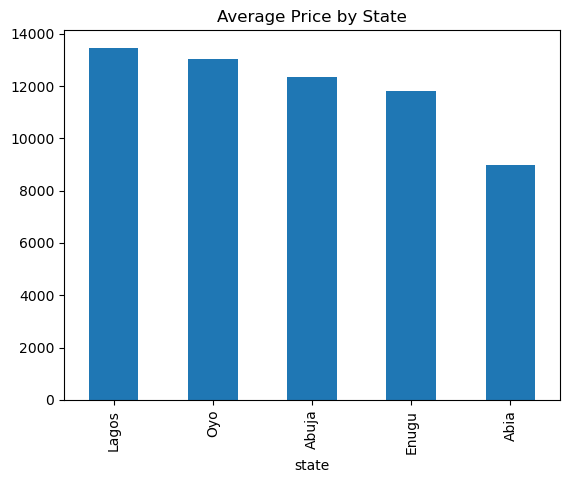

In [237]:
# Your code here

state_avg_price = (
    df.groupby('state')['price']
    .mean()
    .sort_values(ascending=False)
)
print(state_avg_price)
state_avg_price.plot(kind='bar', title='Average Price by State')

**Interpretation:**

States with higher average food prices may reflect supply chain constraints, transportation costs, or urban demand pressures. Persistent price disparities could contribute to unequal food access across regions and highlight areas that may require targeted food security monitoring.

#### Question 8b: Which food items are most frequently sold across markets?




In [238]:
# Your code here
product_frequency = df['product'].value_counts()
print(product_frequency)



product
Rice        216
Tomatoes    207
Beans       196
Gari        193
Yam         188
Name: count, dtype: int64


**Interpretation:**

Rice appears as the most frequently observed commodity across markets, followed closely by tomatoes, beans, gari, and yam. This pattern suggests that these foods represent dietary staples with consistent market availability. Because of their central role in household consumption, monitoring their prices is important for assessing food affordability and nutrition security

#### Question 8c: How do food prices change over time?



date
2024-01    12218.107273
2024-02    11609.138596
2024-03    12500.782095
2024-04    15281.571429
2024-05    14586.083333
2024-06     7786.222222
2024-07     7422.777778
2024-08    14034.694444
2024-09     9600.861111
2024-10     5167.035714
2024-11    14694.090909
2024-12     8370.000000
Freq: M, Name: price, dtype: float64


<Axes: title={'center': 'Average Price Trend Over Time'}, xlabel='date'>

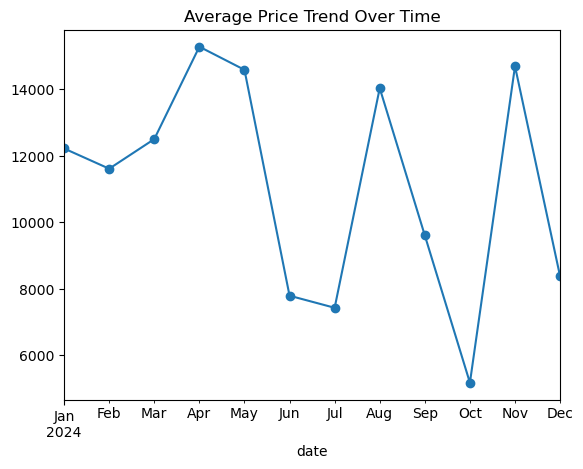

In [239]:
# Your code here
monthly_trend = (
    df.groupby(df['date'].dt.to_period('M'))['price']
    .mean()
)
print(monthly_trend)
monthly_trend.plot(kind='line', marker='o', title='Average Price Trend Over Time')


**Interpretation:**

The monthly trend shows noticeable fluctuations in average food prices across the year. Prices increased between March and April and remained relatively high in May, which may reflect seasonal supply constraints or increased demand during that period. A sharp decline is observed around June and July, followed by another rise in August and November, suggesting cyclical market dynamics likely influenced by harvest seasons, storage patterns, and transportation factors.

---
## Bonus Challenge (Optional, +10 points)

### Bonus: Advanced Analysis

Choose ONE of the following challenges:

**Option A: Multi-dataset Merge**
- Load a second related dataset
- Merge/join the two datasets appropriately
- Perform analysis that requires both datasets
- Provide insights from the combined data

**Option B: Time Series Analysis**
- Use a time-series dataset (or convert your data to time-indexed)
- Calculate daily/weekly/monthly aggregations
- Identify trends or patterns over time
- Find anomalies or outliers

**Option C: Custom Aggregation Function**
- Write a custom function to apply to grouped data
- Use `.apply()` or `.agg()` with your function
- Solve a problem that requires custom logic
- Explain why built-in functions weren't sufficient

**Deliverable:** Complete ONE option with code and explanation

In [240]:
# Your bonus code here (if attempting)
prices = pd.read_csv(r"C:\Users\GOIT\Downloads\ai4sid\class_training\mahis-class\05_datasets\week_02\NumPy & Pandas\nigerian_market_prices_assignment.csv")
transactions = pd.read_csv(r"C:\Users\GOIT\Downloads\ai4sid\class_training\mahis-class\05_datasets\week_02\NumPy & Pandas\nigerian_market_transactions_assignment.csv")

In [241]:
# Preview columns before merging and cleaning
print("Prices columns:", prices.columns.tolist())
print("Transactions columns:", transactions.columns.tolist())

# data cleaning and standardization
if 'transaction_date' in transactions.columns:
    transactions = transactions.rename(columns={'transaction_date': 'date'})

def clean_text_col(df, col):
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

text_cols = ['product', 'market_name', 'trader_name', 'state', 'unit']
for col in text_cols:
    clean_text_col(prices, col)
    clean_text_col(transactions, col)

for df in (prices, transactions):
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

# Show cleaned heads
print(prices.head(3))
print(transactions.head(3))

Prices columns: ['market_id', 'market_name', 'state', 'product', 'price', 'unit', 'date', 'trader_name']
Transactions columns: ['transaction_id', 'market_id', 'trader_id', 'trader_name', 'product', 'quantity', 'revenue', 'payment_method', 'transaction_date']
  market_id    market_name  state product   price    unit       date  \
0    MKT001  Bodija Market    Oyo   Beans  ₦5,770      Kg 2024-02-01   
1    MKT003  Ogbete Market  Enugu     Yam  ₦2,534  Basket        NaT   
2    MKT001  Bodija Market    Oyo     Yam     NaN    50Kg        NaT   

   trader_name  
0  Mama Nkechi  
1        Bello  
2  Alhaji Musa  
  transaction_id market_id trader_id  trader_name   product  quantity  \
0        TXN0001    MKT005     TR005  Alhaji Musa      Gari         8   
1        TXN0002    MKT004     TR001       Sadiya     Beans        14   
2        TXN0003    MKT002     TR006  Alhaji Musa  Tomatoes         8   

   revenue payment_method                date  
0    86160       Transfer 2024-03-02 13:53:

In [242]:
# Merge datasets
merged_df = pd.merge(
    prices,
    transactions,
    on=['market_id'],
    how='inner'
)

merged_df.head()

,market_id,market_name,state,product_x,price,unit,date_x,trader_name_x,transaction_id,trader_id,trader_name_y,product_y,quantity,revenue,payment_method,date_y
0,MKT001,Bodija Market,Oyo,Beans,"₦5,770",Kg,2024-02-01,Mama Nkechi,TXN0006,TR013,Mama Nkechi,Yam,4,185428,POS,NaT
1,MKT001,Bodija Market,Oyo,Beans,"₦5,770",Kg,2024-02-01,Mama Nkechi,TXN0007,TR010,Alhaji Musa,Rice,2,53156,Transfer,2024-09-01 17:34:00
2,MKT001,Bodija Market,Oyo,Beans,"₦5,770",Kg,2024-02-01,Mama Nkechi,TXN0011,TR002,Chinedu,Beans,19,694298,Transfer,2024-12-03 12:02:00
3,MKT001,Bodija Market,Oyo,Beans,"₦5,770",Kg,2024-02-01,Mama Nkechi,TXN0012,TR005,Chinedu,Gari,17,750040,Transfer,NaT
4,MKT001,Bodija Market,Oyo,Beans,"₦5,770",Kg,2024-02-01,Mama Nkechi,TXN0014,TR005,Sadiya,Tomatoes,18,482760,Transfer,NaT


---
## Reflection (Required)

Answer these questions:

1. **What was the most challenging part of this assignment?**
   
   The most challenging aspect of the assignment was data cleaning, particularly standardizing unit measurements across commodities to enable meaningful price comparisons. Determining reasonable conversion assumptions required analytical judgment and highlighted how data quality issues can influence results. This process improved my understanding of the importance of preprocessing in real world data analysis.

2. **What NumPy/Pandas concept do you still find confusing?**
   
   None for now

3. **How will you use NumPy/Pandas in your problem domain project?**
   
   NumPy and Pandas will be used as core tools for data management and exploratory analysis within the project. Pandas will support data cleaning, including handling missing values, standardizing categorical variables, and transforming date and price fields to enable consistent analysis. Additionally, grouping and aggregation functions will be used to examine geographic price differences, product frequency, and temporal trends

4. **What additional data would help you solve your problem?**
   
   Several additional data elements would strengthen the analysis and improve interpretation. First, detailed unit weight information specific to each commodity would reduce uncertainty in price standardization and allow more accurate affordability comparisons. Second, household income or expenditure data would help assess the real impact of price changes on food affordability and food security.

   Other useful data would include seasonal production or harvest information to better explain observed price fluctuations, as well as transportation or supply chain indicators that may influence regional price disparities. Incorporating these data sources would provide a more comprehensive understanding of the drivers of food price variability and its implications for household access to food.

---
## Submission Checklist

Before submitting, ensure:
- [ ] All code cells run without errors
- [ ] All questions are answered
- [ ] Code has comments explaining logic
- [ ] Results are clearly labeled
- [ ] Interpretations are provided for Question 8
- [ ] Reflection questions are answered
- [ ] Notebook is saved with your name in the filename

**Good luck! 🚀**